## Question 3: Exploring Anonymized Data - Can You Find the Golden Feature?



**What is Anonymized Data?**



Anonymized data is information that has been processed to remove or obscure personally identifiable details, making it impossible to trace back to specific individuals. In credit risk modeling, features are often anonymized (e.g., `P_2`, `D_39`, `B_1`) to protect customer privacy while still enabling powerful predictive analytics.



**The Challenge:**



Credit default prediction is central to managing risk in consumer lending. American Express, the world's largest payment card issuer, uses machine learning to predict whether cardholders will default on their payments. This helps optimize lending decisions and creates a better customer experience.



You are provided with an anonymized dataset containing behavioral and profile features. Your objective is to build a classification model that predicts credit default (0 = No Default, 1 = Default).



**Your Mission:** Can you discover the 'golden feature' - the most powerful predictor hidden in this anonymized data?



Your work will be evaluated based on the completion of the following tasks:


# Part 1: Read Data



**Tasks:**



1. Read the dataset `Q3_data.csv` using `read_csv()`

2. Inspect the first few rows using `head()`

3. Display dataset information using `info()`

4. Show statistical description using `describe()`

5. Plot the target distribution (target column)"


In [3]:
import kagglehub



# Download latest version

path = kagglehub.dataset_download("mohammad2012191/q3-ka-ai-2026")



print("Path to dataset files:", path)

100%|██████████| 7.64M/7.64M [00:02<00:00, 2.90MB/s]

Extracting files...


Path to dataset files: C:\Users\moham\.cache\kagglehub\datasets\mohammad2012191\q3-ka-ai-2026\versions\1


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# The 'path' variable is defined in the download cell
df = pd.read_csv(os.path.join(path, 'Q3_data.csv'))


In [5]:
df.head()


,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,Target
0,0.938469,0,0.008724,1.006838,0.009228,0.124035,0.0,0.004709,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.000610,0.0,0
1,0.929122,13,0.025782,1.002647,0.005515,0.089799,0.0,0.005830,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.000027,0.0,0
2,0.876615,0,0.001472,0.810796,0.005955,NaN,0.0,0.004826,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.002738,0.0,0
3,0.567442,9,0.070311,0.812053,0.004228,0.407420,0.0,0.010927,NaN,0.006633,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.001873,0.0,0
4,0.936842,0,0.003433,0.818691,0.007243,0.166190,0.0,0.005927,NaN,0.061963,...,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.003867,0.0,0


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20001 entries, 0 to 20000
Columns: 189 entries, P_2 to Target
dtypes: float64(148), int64(41)
memory usage: 28.8 MB


In [7]:
df.describe()


,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,Target
count,19227.000000,20001.000000,20001.000000,19913.000000,2.000100e+04,16142.000000,19913.000000,1.991300e+04,4846.000000,12372.000000,...,568.000000,568.000000,17892.000000,18692.000000,17892.000000,3143.000000,17892.000000,1.869000e+04,17892.000000,20001.000000
mean,0.657518,4.002250,0.111889,0.656950,5.717425e-02,0.220882,0.043126,1.032376e-01,0.190099,0.146987,...,0.010563,0.336268,0.175665,0.018778,0.162053,0.389692,0.175497,5.278575e-02,0.606696,0.263437
std,0.229293,8.047524,0.200363,0.376335,1.812706e-01,0.174875,0.173998,2.064031e-01,0.249012,0.194166,...,0.102324,0.539078,0.380546,0.135744,0.351676,0.232501,0.380403,1.841938e-01,2.005962,0.440508
min,-0.265757,0.000000,-0.079196,0.000024,8.755637e-08,-0.163072,0.000000,1.323113e-07,-0.000226,0.000034,...,0.000000,0.000000,0.000000,0.000000,0.000000,-0.005664,0.000000,8.393200e-07,0.000000,0.000000
25%,0.485759,0.000000,0.008534,0.216182,2.792879e-03,0.130907,0.000000,4.528223e-03,0.038209,0.042283,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.206377,0.000000,2.741387e-03,0.000000,0.000000
50%,0.680687,0.000000,0.028057,0.814791,5.587010e-03,0.166068,0.000000,8.630981e-03,0.121902,0.086722,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.389914,0.000000,5.481348e-03,0.000000,0.000000
75%,0.856405,5.000000,0.110502,1.001569,8.260199e-03,0.256267,0.000000,8.495419e-02,0.253785,0.175953,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.548646,0.000000,8.288856e-03,0.000000,1.000000
max,1.009957,181.000000,1.324053,1.009997,2.255852e+00,1.854302,3.940222,1.395451e+00,4.181061,3.136848,...,1.000000,4.000000,1.000000,1.000000,1.244915,1.793520,1.000000,1.342693e+00,47.000000,1.000000


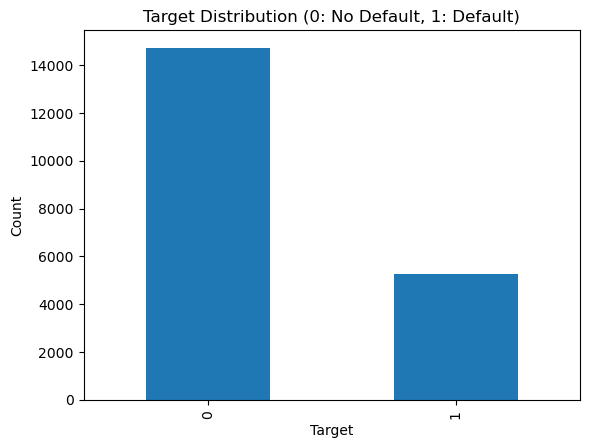

In [9]:
df['Target'].value_counts().plot(kind='bar')
plt.title('Target Distribution (0: No Default, 1: Default)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()


# Part 2: Data Cleaning



**Tasks:**



Inspect and fix the following when needed:



1. **Handle missing values appropriately**

2. **Check and remove duplicates** if any exist

3. **Encode categorical variables** if needed

4. **Apply feature scaling** to numerical features (Use StandardScaler)

5. **Check for target imbalance and state if it is imbalanced or not**

In [10]:
print(df.isnull().sum())
df = df.fillna(df.median())


P_2         774
D_39          0
B_1           0
B_2          88
R_1           0
          ...  
D_142     16858
D_143      2109
D_144      1311
D_145      2109
Target        0
Length: 189, dtype: int64


In [11]:
print(f'Duplicates: {df.duplicated().sum()}')
df = df.drop_duplicates()


Duplicates: 0


In [12]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    le = LabelEncoder()
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col].astype(str))
    print(f'Encoded columns: {list(categorical_cols)}')


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_cols = df.drop(columns=['Target']).columns
df[X_cols] = scaler.fit_transform(df[X_cols])


In [16]:
df['Target'].value_counts()
# there is imbalance

Target
0    14732
1     5269
Name: count, dtype: int64

# Part 3: Modeling



**Tasks:**



1. Split the dataset into features (X) and target (y)

2. Use the correct split: **KFold** OR **StratifiedKFold**

3. Train a **CatBoostClassifier** model

4. Evaluate using the appropriate metric only (Accuracy vs. F1 Score).

5. Print the averaged score across all folds

In [30]:
X = df.drop(columns=['Target'])
y = df['Target']


In [31]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = CatBoostClassifier(n_estimators=100, random_state=42)

f1 = []

for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    f1.append(f1_score(y_val, preds))

print(f'F1: {np.mean(f1):.4f}')


Learning rate set to 0.278031
0:	learn: 0.5071552	total: 12.9ms	remaining: 1.27s
1:	learn: 0.4416210	total: 24.1ms	remaining: 1.18s
2:	learn: 0.4090235	total: 34.3ms	remaining: 1.11s
3:	learn: 0.3823541	total: 45.6ms	remaining: 1.09s
4:	learn: 0.3647924	total: 57.5ms	remaining: 1.09s
5:	learn: 0.3560321	total: 69.4ms	remaining: 1.09s
6:	learn: 0.3487671	total: 80.8ms	remaining: 1.07s
7:	learn: 0.3426778	total: 91.9ms	remaining: 1.06s
8:	learn: 0.3390958	total: 104ms	remaining: 1.05s
9:	learn: 0.3359418	total: 115ms	remaining: 1.03s
10:	learn: 0.3333409	total: 126ms	remaining: 1.02s
11:	learn: 0.3305012	total: 137ms	remaining: 1.01s
12:	learn: 0.3283562	total: 149ms	remaining: 997ms
13:	learn: 0.3265867	total: 161ms	remaining: 989ms
14:	learn: 0.3249902	total: 173ms	remaining: 978ms
15:	learn: 0.3232359	total: 183ms	remaining: 962ms
16:	learn: 0.3214414	total: 194ms	remaining: 950ms
17:	learn: 0.3197878	total: 207ms	remaining: 942ms
18:	learn: 0.3182859	total: 218ms	remaining: 931ms
19:

# Part 4: Find the Golden Feature!



**Tasks:**



1. Plot feature importance from your trained model

2. Identify and print the name of the most important feature (the 'golden feature')

3. Plot the distribution of predictions

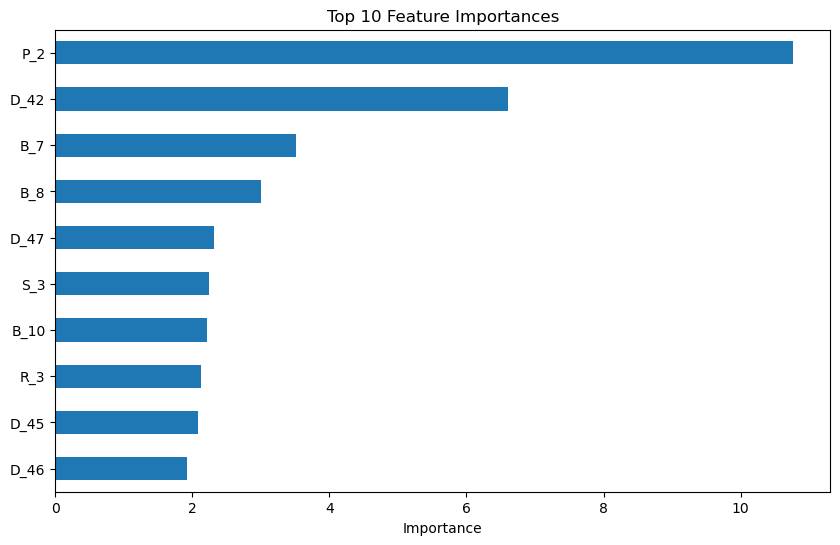

In [34]:
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importances[:10].plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.show()


In [35]:
golden_feature = feat_importances.index[0]
print(f'The Golden Feature is: {golden_feature}')
print(f'Importance: {feat_importances.iloc[0]:.4f}')


The Golden Feature is: P_2
Importance: 10.7680


# Part 5: Bonus - Retrain with Golden Feature Only



**Task:**



Now that you've found the golden feature, let's see how powerful it really is!



Retrain your CatBoostClassifier using **ONLY the golden feature** and compare its performance to the full model:



1. Create new X with only the golden feature

2. Run the same KFold loop with this single feature

3. Print and compare the accuracy with the full model

In [36]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = CatBoostClassifier(n_estimators=100, random_state=42)

# Retrain with only the golden feature
X_golden = X[[golden_feature]]

golden_accuracies = []
for train_idx, val_idx in skf.split(X_golden, y):
    X_train, X_val = X_golden.iloc[train_idx], X_golden.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    golden_accuracies.append(f1_score(y_val, preds))

print(f'Accuracy with ONLY {golden_feature}: {np.mean(golden_accuracies):.4f}')
print(f'Full Model Accuracy: {np.mean(f1):.4f}')
print(f'Difference: {np.mean(f1) - np.mean(golden_accuracies):.4f}')


Learning rate set to 0.278031
0:	learn: 0.5862554	total: 2.37ms	remaining: 234ms
1:	learn: 0.5239659	total: 5.02ms	remaining: 246ms
2:	learn: 0.4843566	total: 7.44ms	remaining: 241ms
3:	learn: 0.4589346	total: 9.64ms	remaining: 231ms
4:	learn: 0.4429755	total: 11.5ms	remaining: 218ms
5:	learn: 0.4308515	total: 13.1ms	remaining: 205ms
6:	learn: 0.4228845	total: 15.8ms	remaining: 210ms
7:	learn: 0.4168093	total: 17.9ms	remaining: 206ms
8:	learn: 0.4131733	total: 20.1ms	remaining: 203ms
9:	learn: 0.4102902	total: 22.7ms	remaining: 204ms
10:	learn: 0.4078257	total: 24.9ms	remaining: 201ms
11:	learn: 0.4058222	total: 26.8ms	remaining: 196ms
12:	learn: 0.4048474	total: 28.5ms	remaining: 191ms
13:	learn: 0.4042916	total: 30.7ms	remaining: 189ms
14:	learn: 0.4034093	total: 32.7ms	remaining: 185ms
15:	learn: 0.4031056	total: 34.6ms	remaining: 182ms
16:	learn: 0.4029442	total: 37ms	remaining: 181ms
17:	learn: 0.4027777	total: 38.8ms	remaining: 177ms
18:	learn: 0.4026397	total: 40.6ms	remaining: 